In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, roc_curve, auc

In [ ]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')


In [ ]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df_nueva_data = df_nueva_data.rename(
    columns = {
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)

In [ ]:
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)

In [ ]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

In [ ]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)

GaussianNB()

In [ ]:
y_pred_gaussian = gaussian.predict(X_test_vec.toarray())
print(y_pred_gaussian)

['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [ ]:
accuracy_g = accuracy_score(y_test, y_pred_gaussian)
print(f"Accuracy GaussianNB: {accuracy_g}")

f1_g = f1_score(y_test, y_pred_gaussian, pos_label = 'spam')
print(f"F1-Score GaussianNB: {f1_g}")

Accuracy GaussianNB: 0.9061004784688995
F1-Score GaussianNB: 0.740495867768595


In [ ]:
report_g = classification_report(y_test, y_pred_gaussian)
print(report_g)

              precision    recall  f1-score   support

         ham       0.98      0.91      0.94      1425
        spam       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



In [ ]:
multinomial = MultinomialNB()
multinomial.fit(X_train_vec, y_train)

MultinomialNB()

In [ ]:
y_pred_multinomial = multinomial.predict(X_test_vec)
print(y_pred_multinomial)

['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [ ]:
accuracy_m = accuracy_score(y_test, y_pred_multinomial)
print(f"Accuracy MultinomialNB: {accuracy_m}")

f1_m = f1_score(y_test, y_pred_multinomial, pos_label = 'spam')
print(f"F1-Score MultinomialNB: {f1_m}")

Accuracy MultinomialNB: 0.9856459330143541
F1-Score MultinomialNB: 0.9504132231404959


In [ ]:
report_m = classification_report(y_test, y_pred_multinomial)
print(report_m)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1425
        spam       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



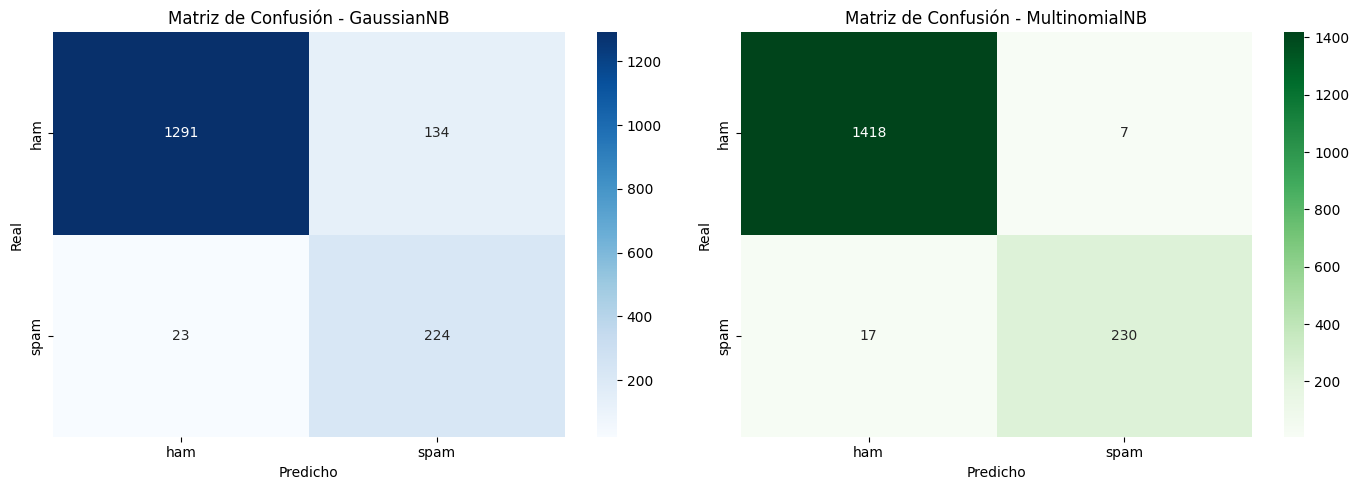

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz GaussianNB
cm_g = confusion_matrix(y_test, y_pred_gaussian)
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=multinomial.classes_, yticklabels=multinomial.classes_)
axes[0].set_title('Matriz de Confusión - GaussianNB', fontsize=12)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz MultinomialNB
cm_m = confusion_matrix(y_test, y_pred_multinomial)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=multinomial.classes_, yticklabels=multinomial.classes_)
axes[1].set_title('Matriz de Confusión - MultinomialNB', fontsize=12)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

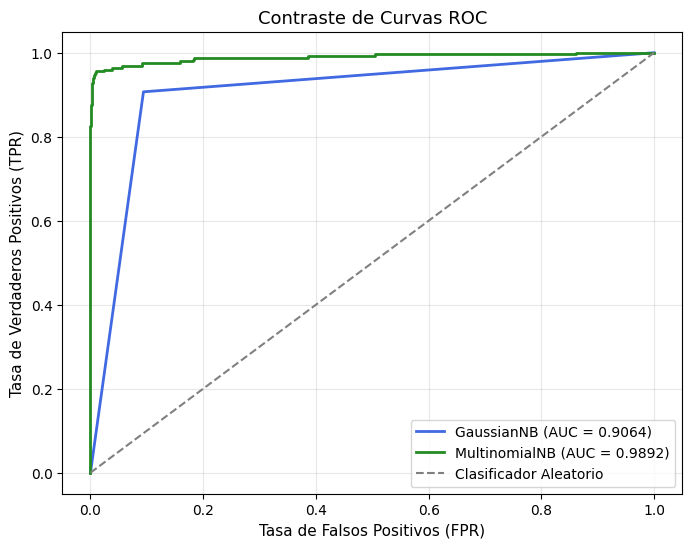

In [ ]:
plt.figure(figsize=(8, 6))

# Estimación de probabilidades para la clase positiva ('spam')
prob_g = gaussian.predict_proba(X_test_vec.toarray())[:, 1]
prob_m = multinomial.predict_proba(X_test_vec)[:, 1]

# Cálculo de tasas y área bajo la curva (AUC)
fpr_g, tpr_g, _ = roc_curve(y_test, prob_g, pos_label='spam')
auc_g = auc(fpr_g, tpr_g)

fpr_m, tpr_m, _ = roc_curve(y_test, prob_m, pos_label='spam')
auc_m = auc(fpr_m, tpr_m)

# Despliegue gráfico
plt.plot(fpr_g, tpr_g, label=f'GaussianNB (AUC = {auc_g:.4f})', color='royalblue', lw=2)
plt.plot(fpr_m, tpr_m, label=f'MultinomialNB (AUC = {auc_m:.4f})', color='forestgreen', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador Aleatorio')

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title('Contraste de Curvas ROC', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Interpretacion:
Idoneidad de la Distribución: El modelo GaussianNB asume variables continuas que siguen una distribución normal. Al transformar texto mediante frecuencias de palabras (CountVectorizer), los datos resultantes son discretos y altamente dispersos (predominancia de ceros). Esto viola los supuestos gaussianos. MultinomialNB modela explícitamente frecuencias de ocurrencia, alineándose con la naturaleza estocástica del texto.

Análisis del Desbalance de Clases: Dado que la proporción de mensajes legítimos (ham) supera ampliamente a los no deseados (spam), la métrica Accuracy tiende a ser engañosa. El incremento del F1-Score en el modelo multinomial demuestra una optimización real en la capacidad de discriminación sin sacrificar la precisión.

Lectura de Matrices y curvas ROC: El contraste visual en las celdas finales expondrá una reducción drástica de falsos positivos y falsos negativos en el esquema multinomial, métricas respaldadas analíticamente por una métrica AUC superior y más cercana a la unidad.